# Assignment-4

This notebook contains the coding questions to test the proficiency in `Object Oriented Programming` in python.

### Date: 10th January, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-04-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-04-Dipika_Chopra.ipynb`.
- Upload the solved notebook in your github repo under the folder **Assignment-4**.
- Upload the solved notebook in the google drive location: https://drive.google.com/drive/folders/1G5M6IcgGvx-hrQ2_iq7xp3Vso9tD_dv0?usp=drive_link
<h3><span style="color:red"> Deadline: 31st Jan, 2026 </span></h3>

## Problem-1

Design a system for a library. Include classes for `Book`, `Patron`, and `Library`.

- The `Book` class should have attributes for title, author, ISBN, and a method `is_available()` that returns `True` if the book is not currently checked out and `False` otherwise. It should also have a method `check_out()` that marks the book as checked out and a method `check_in()` that marks it as available.
- The `Patron` class should have attributes for name and patron ID and a method `borrow_book(book)` that associates a book with the patron.
- The `Library` class should have a collection of `Book` objects and `Patron` objects. It should have methods to `add_book(book)`, `add_patron(patron)`, `lend_book(book, patron)`, and `return_book(book)`. The `lend_book` method should only allow a book to be lent if it's available and the patron exists in the library.


Test your implementation.

In [18]:
class Book:
    def __init__(self, title, author, isbn):
        self.title = title
        self.author = author
        self.isbn = isbn
        self.checked_out = False

    def __str__(self):
        return f"{self.title} by {self.author} (ISBN: {self.isbn})"

    def is_available(self):
        return not self.checked_out

    def check_out(self):
        if self.is_available():
            print(f"The Book {self.title} has checked out")
            self.checked_out = True
        else:
            return False

    def check_in(self):
        if self.checked_out:
            self.checked_out = False
            print(f"The Book {self.title} has checked in")
            return True
        else:
            return False

class Patron:

    def __init__(self,name,patronid):
        self.name=name
        self.patronid=patronid
        self.borrowed_books=[]

    def borrow_book(self,book):
        return self.borrowed_books.append(book)

    def return_book(self, book):
        if book in self.borrowed_books:
            self.borrowed_books.remove(book)

    def __repr__(self):
        return f"Patron({self.name}, ID={self.patronid})"

class Library:

    def __init__(self):
        self.books=[]
        self.patrons=[]

    def add_book(self,book):
        self.books.append(book)

    def add_patron(self,patron):
        self.patrons.append(patron)

    def lend_book(self,book,patron):
        if patron not in self.patrons:
            raise Exception("Patron is not registered in the library.")

        if book not in self.books:
            raise Exception("Book does not belong to this library.")

        if not book.is_available():
            raise Exception("Book is not available for lending.")

        book.check_out()
        patron.borrow_book(book)
        print(f"'{book.title}' has been lent to {patron.name}.")

    def return_book(self, book):
        if book not in self.books:
            raise Exception("Book does not belong to this library.")

        book.check_in()
        for patron in self.patrons:
            patron.return_book(book)

        print(f"'{book.title}' has been returned to the library.")    

In [19]:
library = Library()


book1 = Book("1984", "George Orwell", "123456")
book2 = Book("Clean Code", "Robert C. Martin", "789101")


patron1 = Patron("Alice", 1)
patron2 = Patron("Bob", 2)


library.add_book(book1)
library.add_book(book2)
library.add_patron(patron1)
library.add_patron(patron2)


library.lend_book(book1, patron1)
print(book1)  

library.return_book(book1)
print(book1)  


library.lend_book(book1, patron2)


print(patron2)

The Book 1984 has checked out
'1984' has been lent to Alice.
1984 by George Orwell (ISBN: 123456)
The Book 1984 has checked in
'1984' has been returned to the library.
1984 by George Orwell (ISBN: 123456)
The Book 1984 has checked out
'1984' has been lent to Bob.
Patron(Bob, ID=2)


## Problem-2

Create an base class `Shape` with an method `area()` and another method `perimeter()`. Then, create classes `Rectangle` and `Circle` that inherit from `Shape` and implement the `area()` method. The `perimeter()` method in `Shape` should raise a `NotImplementedError`. Implement the `perimeter()` method in `Rectangle` and `Circle`.

Test your implementation.

In [16]:
import math

class Shape:

    def area(self):
        return NotImplementedError("Subclass need to implement the area() method")

    def perimeter(self):
        return NotImplementedError("Subclass need to implement the perimeter() method")

class Rectangle(Shape):
    def __init__(self,length,width):
        self.length = length
        self.width = width

    def area(self):
        return self.length * self.width

    def perimeter(self):
        return 2 * (self.length + self.width)

class Circle(Shape):
    def __init__(self,radius):
        self.radius = radius
    
    def area(self):
        return math.pi * self.radius ** 2
    
    def perimeter(self):
        return 2 * math.pi * self.radius


In [17]:
r1=Rectangle(30,40)
print(f"The Area of a 'rectangle' is {r1.area()}")
print(f"The Perimeter of a 'rectangle' is {r1.perimeter()}")

c1=Circle(30)
print(f"The Area of a 'circle' is {c1.area()}")
print(f"The Perimeter of a 'circle' is {c1.perimeter()}")

The Area of a 'rectangle' is 1200
The Perimeter of a 'rectangle' is 140
The Area of a 'circle' is 2827.4333882308138
The Perimeter of a 'circle' is 188.49555921538757


## Problem-3

Design a system to model different types of employees in a company. There should be a base `Employee` class with attributes for `name` and `employee_id`. Create two subclasses: `SalariedEmployee` with an attribute for `monthly_salary` and a method `calculate_paycheck()` that returns the monthly salary, and `HourlyEmployee` with attributes for `hourly_rate` and `hours_worked`, and a `calculate_paycheck()` method that returns the total pay for the week. Demonstrate creating instances of both employee types and calling their `calculate_paycheck()` methods.

Test your implementation.

In [14]:
class Employee:
    def __init__(self,name,employee_id):
        self.name=name
        self.employee_id=employee_id

class SalariedEmployee(Employee):
    def __init__(self,name,employee_id,monthy_salary):
        super().__init__(name,employee_id)
        self.monthy_salary=monthy_salary

    def calculate_paycheck(self):
        return self.monthy_salary

class HourlyEmployee(Employee):
    def __init__(self, name, employee_id, hourly_rate, hours_worked):
        super().__init__(name, employee_id)
        self.hourly_rate=hourly_rate
        self.hours_worked=hours_worked
    
    def calculate_paycheck(self):
        return self.hourly_rate * self.hours_worked


In [15]:
salary_person1 = SalariedEmployee("Govardhan","S25001",70000)
hourly_person1 = HourlyEmployee("Kowshik","H25001",200,48)

print(f"Salaried Employee Paycheck Rs:{salary_person1.calculate_paycheck()}")
print(f"Hourly Employee Paycheck Rs:{hourly_person1.calculate_paycheck()}")

Salaried Employee Paycheck Rs:70000
Hourly Employee Paycheck Rs:9600


## Problem-4

Design a class `polynomial` of one variable which will have attributes `degree`, a positive integer and `coefficients`, a list of floating point numbers. 
`degree` means the highest power of the variable and `coefficients` are the coefficient of individual terms.

A polynomial of degree `n` has `n+1` coefficients. 

- Example-1:
$$ 3x^4 + 5x^3 + x^2 + 9x + 10 $$
This is a polynomial of degree 4 and coefficients are [3, 5, 1, 9, 10].

- Example-2: (some coefficients could be zero)
$$ 0.7x^3 + 2.5x $$
Here the degree of polynomial is 3 and coefficients are [0.7, 0, 2.5, 0].

A polynomial of degree zero is just a constant value. 

In the `polynomial` class, you need to implement the following methods:
- `evaluate(x)` which will evaluate the polynomial for a given value of the variable x.
- `plot([x1, x2])` this will plot the polynomial for a given range of x1 to x2 of the variable.
- `derivative(x)` This will evaluate the derivative (differentiation) of the polynomial for a given value of the variable x.
- `plot_derivative([x1, x2])` this will plot the derivative of the polynomial for a given range of x1 to x2 of the variable.

The class should have basic checks, such that the number of coefficients provided by the user should be degree + 1 and the degree should be a positive integer. 

Test your implementation. 

In [11]:
import matplotlib.pyplot as plt 
import numpy as np

class Polynomial:
    def __init__(self,degree,coefficients):
        if type(degree)!=int or degree < 0:
            raise ValueError("Degree must be a non-negative integer")
        
        if len(coefficients) != degree+1:
            raise ValueError("Number of coefficients must be degree + 1")
        self.degree = degree
        self.coefficients = coefficients
    
    def evaluate(self,x):
        result = 0
        power = self.degree

        for coef in self.coefficients:
            result += coef * (x**power)
            power -= 1

        return result
    
    def plot(self,x_range):
        x1,x2 = x_range
        x_values = np.linspace(x1,x2,100)
        y_values = [self.evaluate(x) for x in x_values]

        plt.plot(x_values,y_values,label="Polynomial")
        plt.xlabel("x")
        plt.ylabel("P(x)")
        plt.title("Polynomial Plot")
        plt.legend()
        plt.grid(True)
        plt.show()

    def derivative(self,x):
        result = 0
        power = self.degree

        for coef in self.coefficients[:-1]:
            result += coef * power * (x ** (power - 1))
            power -= 1
        
        return result
    
    def plot_derivative(self,x_range):
        x1,x2 = x_range
        x_values = np.linspace(x1,x2,100)
        y_values = [self.derivative(x) for x in x_values]

        plt.plot(x_values, y_values, color="red", label="Derivative")
        plt.xlabel("x")
        plt.ylabel("P'(x)")
        plt.title("Derivative Plot")
        plt.legend()
        plt.grid(True)
        plt.show()


P(2) = 120
P'(2) = 169


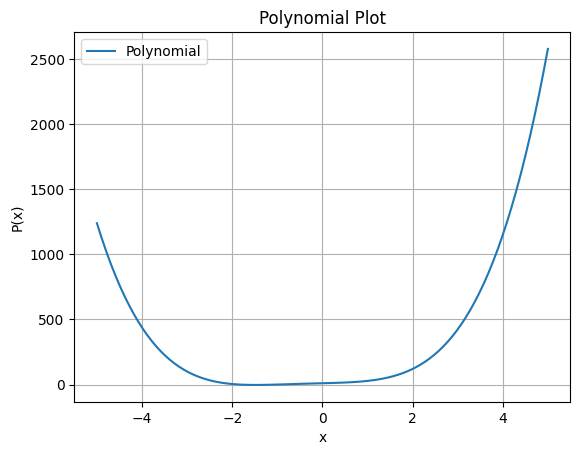

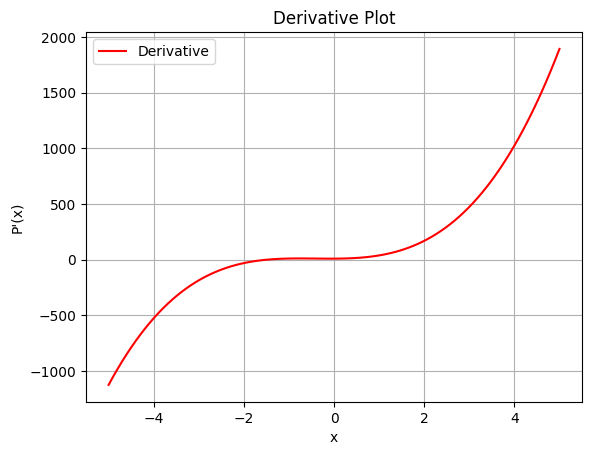

P(1) = 3.2
P'(1) = 4.6


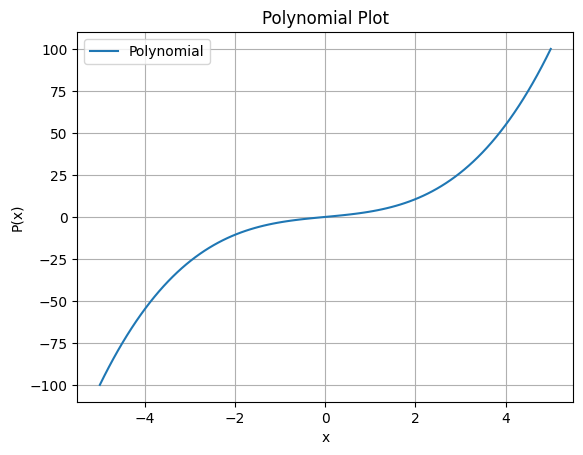

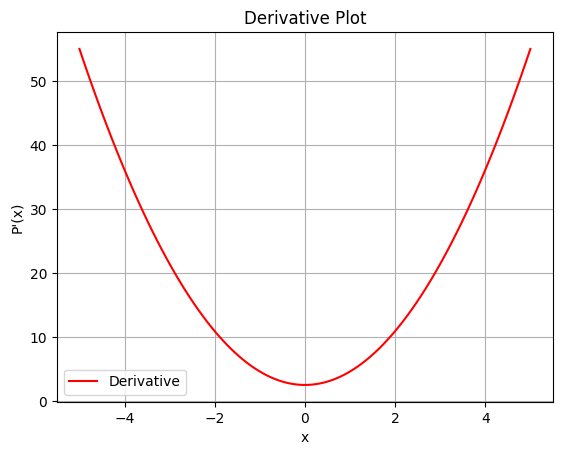

In [13]:
p1 = Polynomial(4, [3, 5, 1, 9, 10])

print("P(2) =", p1.evaluate(2))
print("P'(2) =", p1.derivative(2))

p1.plot([-5, 5])
p1.plot_derivative([-5, 5])

p2 = Polynomial(3, [0.7, 0, 2.5, 0])

print("P(1) =", p2.evaluate(1))
print("P'(1) =", p2.derivative(1))

p2.plot([-5, 5])
p2.plot_derivative([-5, 5])

## Problem-5

Design a system to model a simple online shopping cart. Create a class `Product` with attributes for `name` and `price`. Then, create a `ShoppingCart` class that has a list to store `Product` objects. Implement methods to `add_item(product)`, `remove_item(product_name)`, and `calculate_total()`.

In [9]:
class Product:
    def __init__(self,name,price):
        self.name = name
        self.price = price

class ShoppingCart:
    def __init__(self):
        self.product_lists = []

    def add_item(self,product):
        self.product_lists.append(product)
        print(f"{product.name} added to cart.")
    
    def remove_item(self,product_name):
        for item in self.product_lists:
            if item.name == product_name:
                self.product_lists.remove(item)
                print(f"{product_name} removed from cart.")
                return
        print(f"{product_name} not found in cart.")

    def calculate_total(self):
        total = 0
        for item in self.product_lists:
            total += item.price
        return total

In [10]:
# Create products
p1 = Product("Laptop", 800)
p2 = Product("Mouse", 25)
p3 = Product("Keyboard", 50)

# Create shopping cart
cart = ShoppingCart()

# Add items
cart.add_item(p1)
cart.add_item(p2)
cart.add_item(p3)

# Remove an item
cart.remove_item("Mouse")

# Calculate total
print("Total amount:", cart.calculate_total())

Laptop added to cart.
Mouse added to cart.
Keyboard added to cart.
Mouse removed from cart.
Total amount: 850
